<a href="https://colab.research.google.com/github/Qibzz/ecommerce-sentiment-trend-analysis/blob/main/project_kecil2an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA ANALYST SECTION

## Business Understanding

Shopee adalah salah satu platform e-commerce terbesar di Asia Tenggara. Sebagai perusahaan berbasis teknologi, **feedback pengguna melalui review aplikasi** merupakan aset penting untuk memahami pengalaman pengguna dan mengidentifikasi area perbaikan.

## Dataset
- **Sumber**: Google Play Store — Aplikasi Shopee (ID)
- **Jumlah Data**: 2.500 reviews (balanced sampling, 500 per rating)
- **Periode**: Juli 2022 – April 2023
- **Bahasa**: Bahasa Indonesia

---
### 1. Import Library & Setup

In [4]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# GLOBAL STYLE
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Shopee brand colors
SHOPEE_ORANGE = '#EE4D2D'
SHOPEE_LIGHT  = '#FF7337'
COLOR_PALETTE = ['#d32f2f','#ef6c00','#f9a825','#558b2f','#1565c0']

print('Library berhasil di-import!')

Library berhasil di-import!


---
### 2. Data Loading & Overview

In [7]:
# Load Data
df = pd.read_csv('Shopee_Sampled_Reviews.csv')

print('=' * 50)
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'Periode data  : {df["at"].min()[:10]} s/d {df["at"].max()[:10]}')
print('=' * 50)

df.head(3)

Jumlah baris  : 2,500
Jumlah kolom  : 10
Periode data  : 2022-07-11 s/d 2023-04-13


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,61ccddf5-2848-47d6-83a7-434e4e613bfa,Andi Gunawan,https://play-lh.googleusercontent.com/a-/ACB-R...,Udah sering belanja trs tapi setiap pengajuan ...,1,1,2.95.47,2022-12-05 13:29:47,"Hi kak, maaf ya buat gak nyaman. terkait kenda...",2022-11-04 16:59:58
1,affdfdc0-0a10-4353-8ba9-52a669f8a1ba,Sari Sari,https://play-lh.googleusercontent.com/a/AGNmyx...,Semenjak di upgrade.. SHOPEE JADI LEMOT,1,0,NaN,2022-12-27 05:36:57,Hi kak maaf atas ketidaknyamannya🙏 Pastiin RAM...,2022-12-27 06:14:13
2,f5a73edb-ae1a-4a1b-93a6-aa2a5fe5217e,Laz Ai,https://play-lh.googleusercontent.com/a/AGNmyx...,Penyelesaian masalah sangat buruk,1,0,NaN,2022-08-15 07:00:00,NaN,NaN


In [8]:
#Data Types & Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              2500 non-null   object
 1   userName              2500 non-null   object
 2   userImage             2500 non-null   object
 3   content               2500 non-null   object
 4   score                 2500 non-null   int64 
 5   thumbsUpCount         2500 non-null   int64 
 6   reviewCreatedVersion  1950 non-null   object
 7   at                    2500 non-null   object
 8   replyContent          1628 non-null   object
 9   repliedAt             1628 non-null   object
dtypes: int64(2), object(8)
memory usage: 195.4+ KB


In [10]:
#Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0')

print('Kolom dengan Missing Values:')
print(missing_df)
print()
print('Catatan: replyContent & repliedAt kosong karena tidak semua review dibalas CS.')

Kolom dengan Missing Values:
                      Jumlah Missing  Persentase (%)
reviewCreatedVersion             550           22.00
replyContent                     872           34.88
repliedAt                        872           34.88

Catatan: replyContent & repliedAt kosong karena tidak semua review dibalas CS.


---
### 3. Data Cleaning & Preprocessing

In [13]:
#Cleaning
df_clean = df.copy()

# 1. Convert datetime
df_clean['at'] = pd.to_datetime(df_clean['at'])
df_clean['repliedAt'] = pd.to_datetime(df_clean['repliedAt'])

# 2. Ekstrak fitur waktu
df_clean['year']        = df_clean['at'].dt.year
df_clean['month']       = df_clean['at'].dt.month
df_clean['month_name']  = df_clean['at'].dt.strftime('%b %Y')
df_clean['day_of_week'] = df_clean['at'].dt.day_name()
df_clean['hour']        = df_clean['at'].dt.hour

# 3. Hitung response time CS (dalam jam)
df_clean['response_time_hours'] = (
    df_clean['repliedAt'] - df_clean['at']
).dt.total_seconds() / 3600

df_clean.loc[df_clean['response_time_hours'] < 0, 'response_time_hours'] = np.nan  # negatif → anomali
df_clean['response_time_hours'] = df_clean['response_time_hours'].fillna(0)  # NaN → 0

# 4. Flag apakah review dibalas
df_clean['is_replied'] = df_clean['replyContent'].notna()

# 5. Panjang review (jumlah karakter)
df_clean['review_length'] = df_clean['content'].str.len()

# 6. Sentimen berdasarkan score
def categorize_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df_clean['sentiment'] = df_clean['score'].apply(categorize_sentiment)

# 7. Drop kolom tidak relevan
df_clean.drop(columns=['userImage'], inplace=True)

print('Data cleaning selesai!')
print(f'   Shape: {df_clean.shape}')
df_clean[['content','score','sentiment','review_length','is_replied','response_time_hours']].head(5)

Data cleaning selesai!
   Shape: (2500, 18)


,content,score,sentiment,review_length,is_replied,response_time_hours
0,Udah sering belanja trs tapi setiap pengajuan ...,1,Negatif,96,True,0.000000
1,Semenjak di upgrade.. SHOPEE JADI LEMOT,1,Negatif,39,True,0.621111
2,Penyelesaian masalah sangat buruk,1,Negatif,33,False,0.000000
3,Apk engga😇 jls,1,Negatif,14,True,1.204167
4,Lelet stress. Udah update terbaru tetap aja lemot,1,Negatif,49,False,0.000000


---
### 4. Exploratory Data Analysis (EDA)

4.1 Distribusi Rating & Sentimen

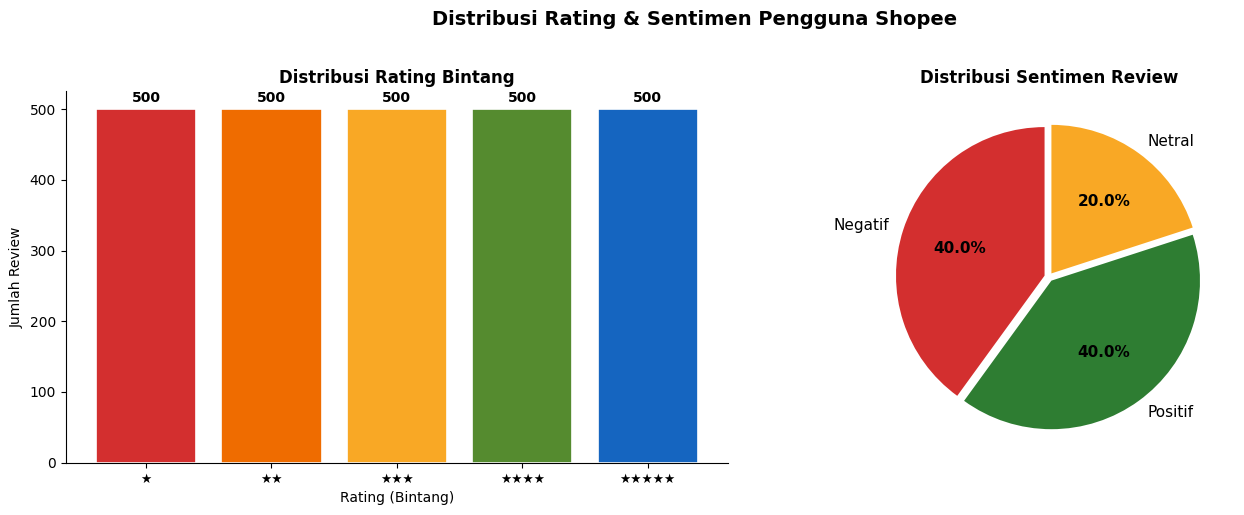


📊 Ringkasan Sentimen:
   Negatif   : 1000 review (40.0%)
   Positif   : 1000 review (40.0%)
   Netral    :  500 review (20.0%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Rating & Sentimen Pengguna Shopee', fontsize=14, fontweight='bold', y=1.02)

#Plot 1: Rating Distribution
ax1 = axes[0]
rating_counts = df_clean['score'].value_counts().sort_index()
bars = ax1.bar(rating_counts.index, rating_counts.values, color=COLOR_PALETTE, edgecolor='white', linewidth=1.2)
ax1.set_title('Distribusi Rating Bintang', fontweight='bold')
ax1.set_xlabel('Rating (Bintang)')
ax1.set_ylabel('Jumlah Review')
ax1.set_xticks([1, 2, 3, 4, 5])
for bar, count in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Star labels
stars = ['★', '★★', '★★★', '★★★★', '★★★★★']
ax1.set_xticklabels(stars, fontsize=9)

#Plot 2: Sentiment Pie
ax2 = axes[1]
sentiment_counts = df_clean['sentiment'].value_counts()
colors_sentiment = {'Negatif': '#d32f2f', 'Netral': '#f9a825', 'Positif': '#2e7d32'}
colors_list = [colors_sentiment[s] for s in sentiment_counts.index]

wedges, texts, autotexts = ax2.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=colors_list,
    startangle=90,
    explode=[0.03]*len(sentiment_counts),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Distribusi Sentimen Review', fontweight='bold')

plt.tight_layout()
plt.savefig('01_rating_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n📊 Ringkasan Sentimen:')
for s, c in sentiment_counts.items():
    pct = c/len(df_clean)*100
    print(f'   {s:10s}: {c:4d} review ({pct:.1f}%)')

4.2 Tren Review Per Bulan

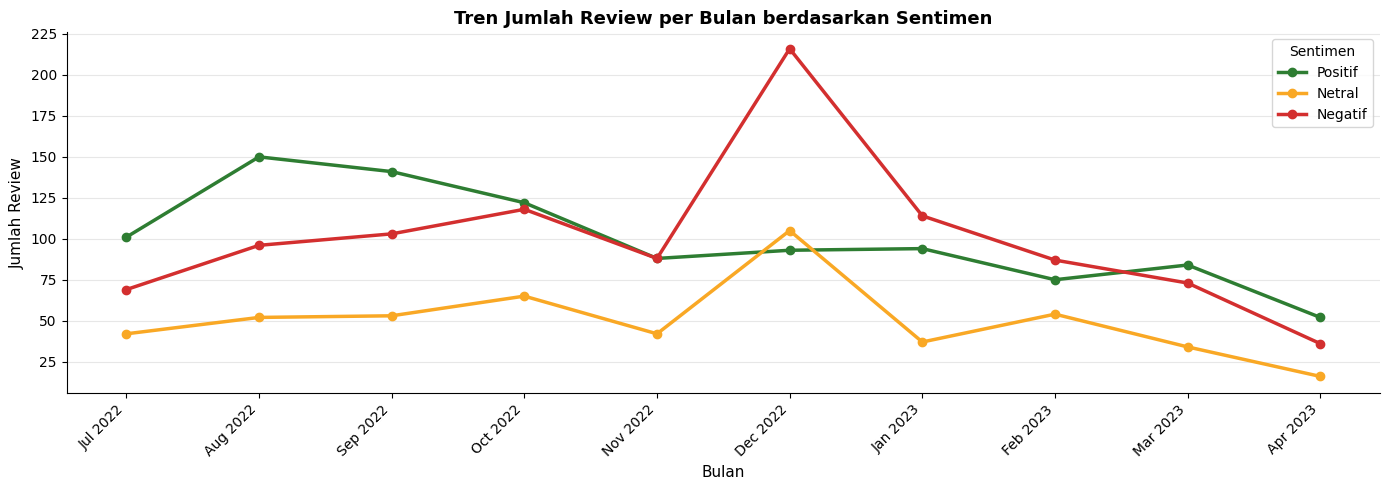


📊 Ringkasan:
 
— Desember 2022 jadi puncak review negatif 
— Review positif konsisten lebih tinggi dari negatif di hampir semua bulan, kecuali Desember 2022 
— Review netral selalu paling sedikit karena pengguna Shopee cenderung ekspresif, kalau senang kasih bintang 5, kalau kecewa langsung bintang 1
— Tren negatif menurun setelah Januari 2023, mengindikasikan ada perbaikan dari pihak Shopee


In [22]:
#Tren Review Per Bulan
monthly = df_clean.groupby(['month_name', 'sentiment']).size().unstack(fill_value=0)

# Sort by actual date
df_clean['month_dt'] = df_clean['at'].dt.to_period('M')
month_order = df_clean.groupby('month_name')['month_dt'].first().sort_values().index.tolist()
monthly = monthly.reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))

sentiment_colors = {'Negatif': '#d32f2f', 'Netral': '#f9a825', 'Positif': '#2e7d32'}
for sent in ['Positif', 'Netral', 'Negatif']:
    if sent in monthly.columns:
        ax.plot(monthly.index, monthly[sent], marker='o', linewidth=2.5,
                markersize=6, label=sent, color=sentiment_colors[sent])

ax.set_title('Tren Jumlah Review per Bulan berdasarkan Sentimen', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Review', fontsize=11)
ax.legend(title='Sentimen', fontsize=10)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n📊 Ringkasan:')
print('''
— Desember 2022 jadi puncak review negatif
— Review positif konsisten lebih tinggi dari negatif di hampir semua bulan, kecuali Desember 2022
— Review netral selalu paling sedikit karena pengguna Shopee cenderung ekspresif, kalau senang kasih bintang 5, kalau kecewa langsung bintang 1
— Tren negatif menurun setelah Januari 2023, mengindikasikan ada perbaikan dari pihak Shopee''')

4.3 Analisis Kata-Kata Paling Sering Muncul

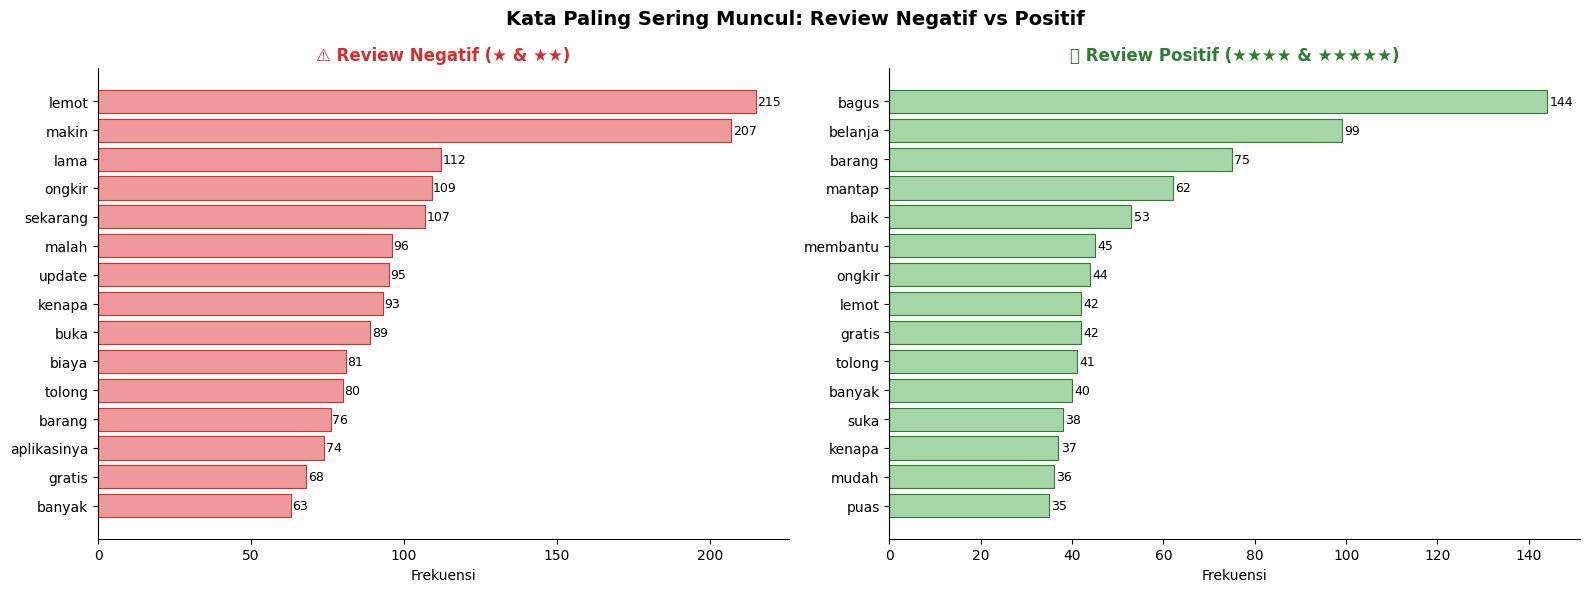

In [23]:
# === TEXT PREPROCESSING ===
STOPWORDS_ID = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'tidak', 'ada', 'saya', 'aku', 'kamu', 'kami', 'kita', 'mereka',
    'sudah', 'sudah', 'bisa', 'juga', 'tapi', 'atau', 'karena', 'jadi',
    'kalau', 'aja', 'ya', 'yg', 'ga', 'gak', 'nggak', 'nya', 'lagi',
    'buat', 'nih', 'sih', 'deh', 'dong', 'banget', 'udah', 'sama',
    'kayak', 'kaya', 'terus', 'masih', 'mau', 'mau', 'lg', 'ny',
    'sy', 'dr', 'dlm', 'sdh', 'dgn', 'tp', 'krn', 'lebih', 'pun',
    'aja', 'kak', 'kalo', 'padahal', 'pas', 'pake', 'atas', 'bawah',
    'semua', 'setiap', 'harus', 'akan', 'lah', 'lho', 'lo', 'gue',
    'shopee', 'aplikasi', 'app', 'apk', 'hi', 'hai', 'maaf', 'terima',
    'kasih', 'terimakasih', 'kamu', 'mimin', 'kan', 'jangan', 'kok',
    'saat', 'baru', 'sangat', 'sekali'
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS_ID and len(w) > 2]
    return tokens

# Pisahkan berdasarkan sentimen
neg_reviews = df_clean[df_clean['sentiment'] == 'Negatif']['content']
pos_reviews = df_clean[df_clean['sentiment'] == 'Positif']['content']

neg_words = [w for text in neg_reviews for w in clean_text(text)]
pos_words = [w for text in pos_reviews for w in clean_text(text)]

neg_freq = Counter(neg_words).most_common(15)
pos_freq = Counter(pos_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Kata Paling Sering Muncul: Review Negatif vs Positif', fontsize=14, fontweight='bold')

# Negatif
ax1 = axes[0]
neg_labels = [w for w, _ in neg_freq]
neg_values = [c for _, c in neg_freq]
bars = ax1.barh(neg_labels[::-1], neg_values[::-1], color='#ef9a9a', edgecolor='#d32f2f', linewidth=0.8)
ax1.set_title('⚠️ Review Negatif (★ & ★★)', fontweight='bold', color='#d32f2f')
ax1.set_xlabel('Frekuensi')
for bar, val in zip(bars, neg_values[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

# Positif
ax2 = axes[1]
pos_labels = [w for w, _ in pos_freq]
pos_values = [c for _, c in pos_freq]
bars2 = ax2.barh(pos_labels[::-1], pos_values[::-1], color='#a5d6a7', edgecolor='#2e7d32', linewidth=0.8)
ax2.set_title('✅ Review Positif (★★★★ & ★★★★★)', fontweight='bold', color='#2e7d32')
ax2.set_xlabel('Frekuensi')
for bar, val in zip(bars2, pos_values[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

4.4 WordCloud Review Negatif & Positif

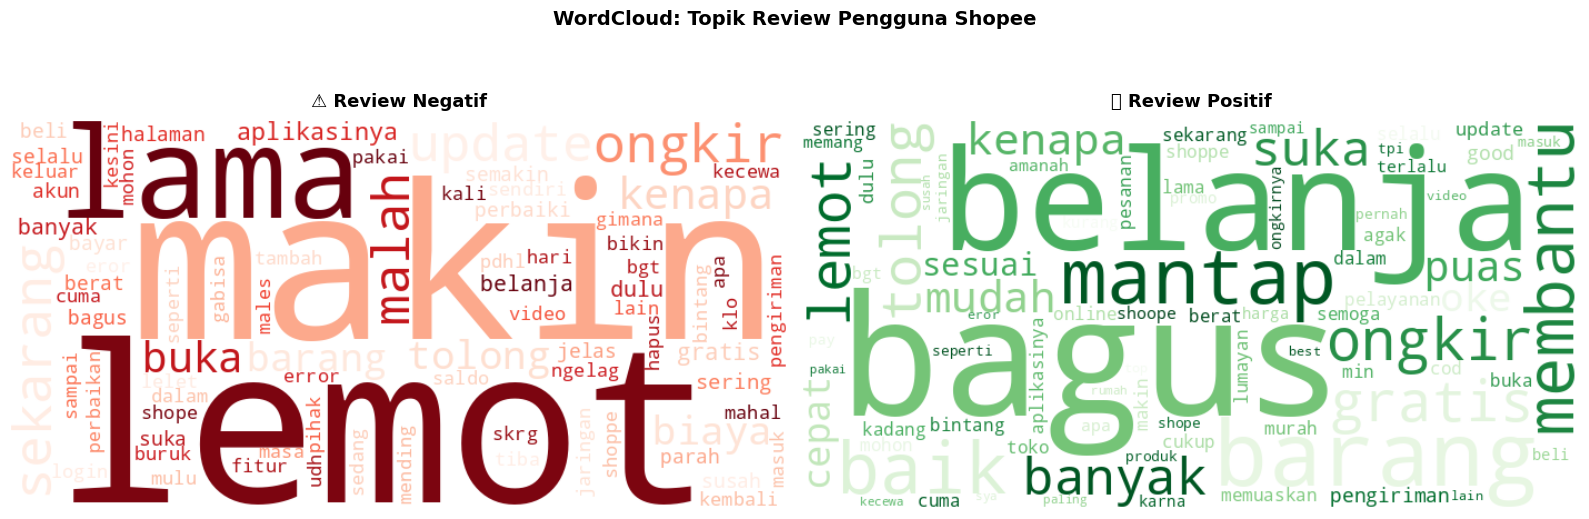

In [24]:
#Wordcloud
def make_wordcloud(words, colormap, title, ax):
    text = ' '.join(words)
    wc = WordCloud(
        width=700, height=350,
        background_color='white',
        colormap=colormap,
        max_words=80,
        stopwords=STOPWORDS_ID,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WordCloud: Topik Review Pengguna Shopee', fontsize=14, fontweight='bold')

make_wordcloud(neg_words, 'Reds', '⚠️ Review Negatif', axes[0])
make_wordcloud(pos_words, 'Greens', '✅ Review Positif', axes[1])

plt.tight_layout()
plt.savefig('04_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

4.5 Analisis Responsivitas Customer Service

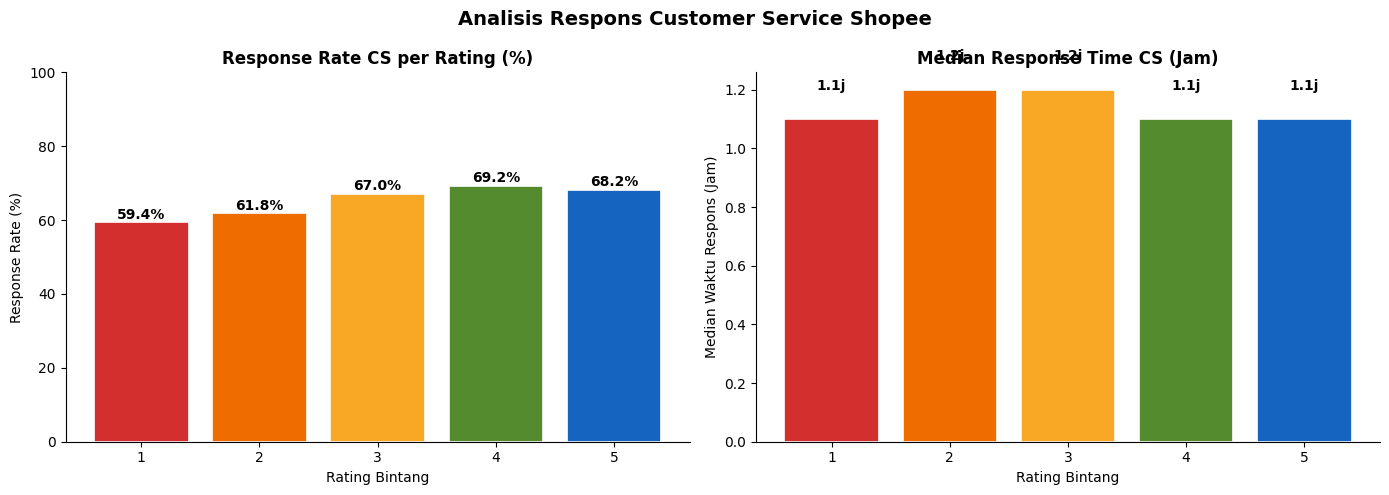


📊 Detail Response Rate CS:
       Dibalas  Total  Rate (%)
score                          
1          297    500      59.4
2          309    500      61.8
3          335    500      67.0
4          346    500      69.2
5          341    500      68.2


In [25]:
#CS Response Analysis
replied_by_score = df_clean.groupby('score')['is_replied'].agg(['sum','count'])
replied_by_score['reply_rate'] = (replied_by_score['sum'] / replied_by_score['count'] * 100).round(1)

avg_response = df_clean[df_clean['is_replied']].groupby('score')['response_time_hours'].median().round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Respons Customer Service Shopee', fontsize=14, fontweight='bold')

# Plot 1: Reply Rate per Rating
ax1 = axes[0]
bars = ax1.bar(replied_by_score.index, replied_by_score['reply_rate'],
               color=COLOR_PALETTE, edgecolor='white', linewidth=1.2)
ax1.set_title('Response Rate CS per Rating (%)', fontweight='bold')
ax1.set_xlabel('Rating Bintang')
ax1.set_ylabel('Response Rate (%)')
ax1.set_ylim(0, 100)
ax1.set_xticks([1, 2, 3, 4, 5])
for bar, rate in zip(bars, replied_by_score['reply_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate}%', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Median Response Time
ax2 = axes[1]
valid_resp = avg_response.dropna()
bars2 = ax2.bar(valid_resp.index, valid_resp.values,
                color=COLOR_PALETTE[:len(valid_resp)], edgecolor='white', linewidth=1.2)
ax2.set_title('Median Response Time CS (Jam)', fontweight='bold')
ax2.set_xlabel('Rating Bintang')
ax2.set_ylabel('Median Waktu Respons (Jam)')
for bar, val in zip(bars2, valid_resp.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}j', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('05_cs_response.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Detail Response Rate CS:')
print(replied_by_score.rename(columns={'sum':'Dibalas','count':'Total','reply_rate':'Rate (%)'}))

4.6 Kategorisasi Topik Keluhan Utama

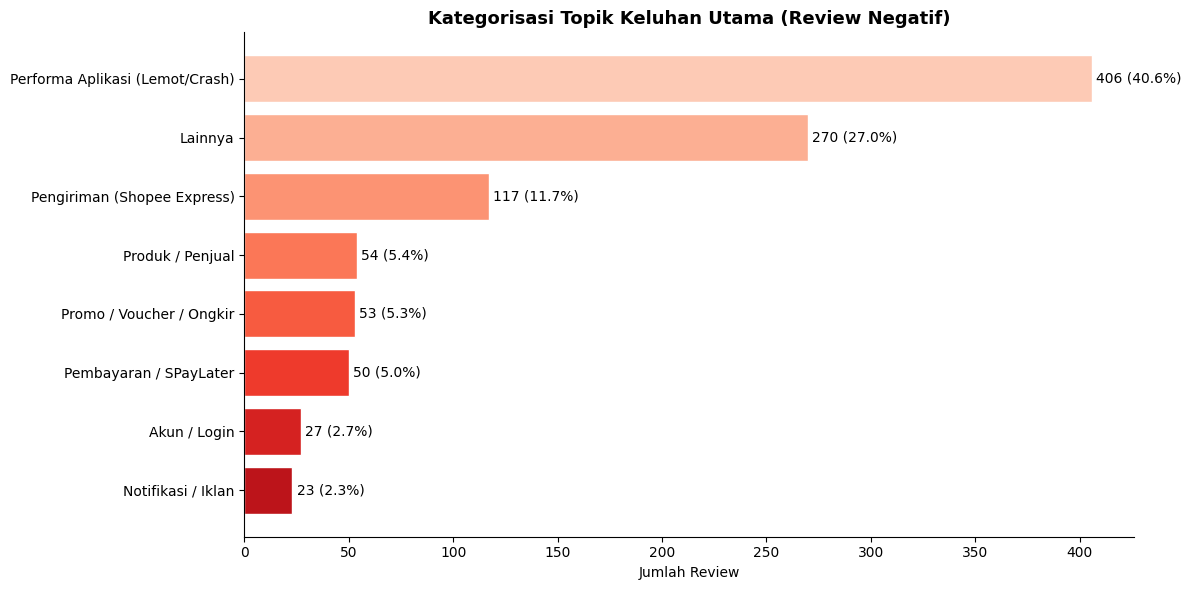

In [26]:
#Topic Categorization
topic_keywords = {
    'Performa Aplikasi (Lemot/Crash)' : ['lemot', 'berat', 'loading', 'crash', 'error', 'lag', 'lambat', 'lelet', 'hang', 'freeze'],
    'Pengiriman (Shopee Express)'      : ['pengiriman', 'kurir', 'express', 'paket', 'lama', 'lambat', 'kirim', 'ekspedisi'],
    'Pembayaran / SPayLater'           : ['paylater', 'spaylater', 'bayar', 'limit', 'tagihan', 'cicilan', 'kredit', 'spinjam'],
    'Produk / Penjual'                 : ['penjual', 'barang', 'produk', 'palsu', 'kualitas', 'seller', 'toko', 'original'],
    'Notifikasi / Iklan'               : ['notifikasi', 'iklan', 'spam', 'video', 'tiktok', 'ganggu', 'notif'],
    'Promo / Voucher / Ongkir'         : ['promo', 'voucher', 'ongkir', 'gratis', 'cashback', 'diskon', 'koin'],
    'Akun / Login'                     : ['akun', 'login', 'password', 'verifikasi', 'suspend', 'banned', 'otp'],
}

def categorize_topic(text):
    text_lower = str(text).lower()
    for topic, keywords in topic_keywords.items():
        if any(kw in text_lower for kw in keywords):
            return topic
    return 'Lainnya'

neg_df = df_clean[df_clean['sentiment'] == 'Negatif'].copy()
neg_df['topic'] = neg_df['content'].apply(categorize_topic)

topic_counts = neg_df['topic'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors_topic = plt.cm.Reds_r(np.linspace(0.2, 0.8, len(topic_counts)))
bars = ax.barh(topic_counts.index[::-1], topic_counts.values[::-1], color=colors_topic, edgecolor='white')

ax.set_title('Kategorisasi Topik Keluhan Utama (Review Negatif)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Review')
for bar, val in zip(bars, topic_counts.values[::-1]):
    pct = val / len(neg_df) * 100
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('06_complaint_topics.png', dpi=150, bbox_inches='tight')
plt.show()

4.7 Pola Waktu Posting Review

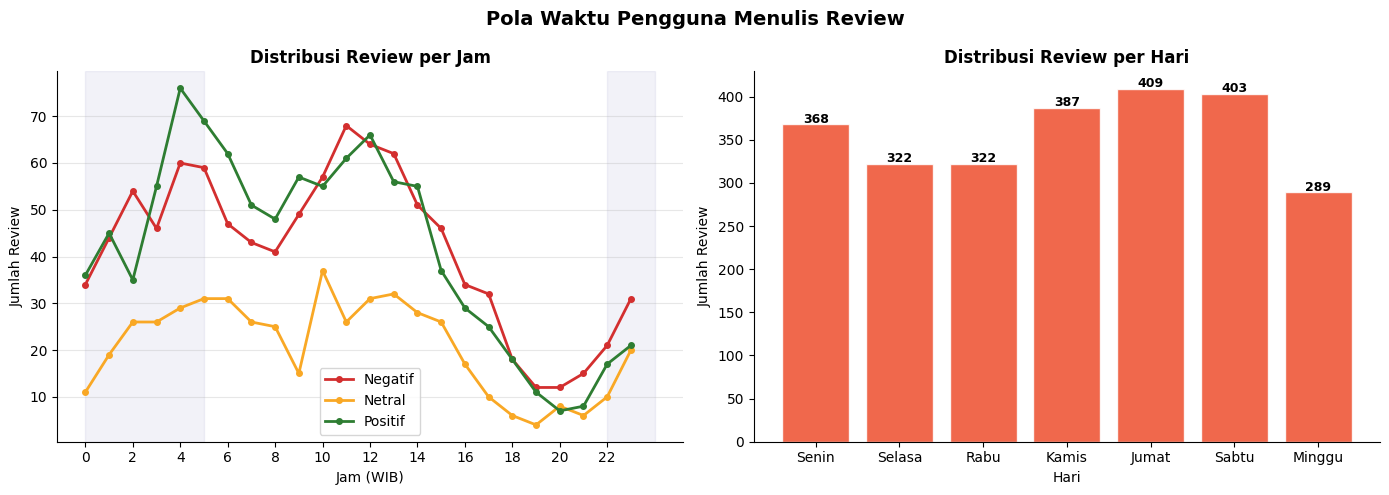


📊 Ringkasan:
 
1. Per Jam: Review paling ramai di jam 4–5 pagi (puncak tertinggi) dan jam 10–12 siang. 
Uniknya jam 4 pagi justru dominan — kemungkinan pengguna yang baru terima/cek paket malam hari langsung nulis review. 
Review anjlok drastis di jam 20–22 malam.
2. Per Hari: Jumat (409) dan Sabtu (403) paling aktif, sementara Minggu (289) paling sepi. Pola ini menunjukkan pengguna lebih sering belanja dan review di akhir pekan kerja, bukan akhir pekan libur.



In [36]:
# Waktu POosting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Waktu Pengguna Menulis Review', fontsize=14, fontweight='bold')

# Plot 1: Per jam
ax1 = axes[0]
hour_counts = df_clean.groupby(['hour', 'sentiment']).size().unstack(fill_value=0)
for sent, color in sentiment_colors.items():
    if sent in hour_counts.columns:
        ax1.plot(hour_counts.index, hour_counts[sent], marker='o', linewidth=2,
                 markersize=4, label=sent, color=color)
ax1.set_title('Distribusi Review per Jam', fontweight='bold')
ax1.set_xlabel('Jam (WIB)')
ax1.set_ylabel('Jumlah Review')
ax1.set_xticks(range(0, 24, 2))
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axvspan(0, 5, alpha=0.05, color='navy', label='Dini hari')
ax1.axvspan(22, 24, alpha=0.05, color='navy')

# Plot 2: Per hari
ax2 = axes[1]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_labels = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
day_counts = df_clean['day_of_week'].value_counts().reindex(day_order).fillna(0)
ax2.bar(day_labels, day_counts.values, color=SHOPEE_ORANGE, alpha=0.85, edgecolor='white')
ax2.set_title('Distribusi Review per Hari', fontweight='bold')
ax2.set_xlabel('Hari')
ax2.set_ylabel('Jumlah Review')
for i, val in enumerate(day_counts.values):
    ax2.text(i, val + 2, str(int(val)), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('07_time_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Ringkasan:')
print('''
1. Per Jam: Review paling ramai di jam 4–5 pagi (puncak tertinggi) dan jam 10–12 siang.
Uniknya jam 4 pagi justru dominan — kemungkinan pengguna yang baru terima/cek paket malam hari langsung nulis review.
Review anjlok drastis di jam 20–22 malam.
2. Per Hari: Jumat (409) dan Sabtu (403) paling aktif, sementara Minggu (289) paling sepi. Pola ini menunjukkan pengguna lebih sering belanja dan review di akhir pekan kerja, bukan akhir pekan libur.
''')

---
### 5. Key Insights & Rekomendasi


In [28]:
total = len(df_clean)
neg_pct = len(df_clean[df_clean['sentiment']=='Negatif'])/total*100
pos_pct = len(df_clean[df_clean['sentiment']=='Positif'])/total*100
neutral_pct = len(df_clean[df_clean['sentiment']=='Netral'])/total*100

print('=' * 60)
print('📌 INSIGHT 1 — Distribusi Kepuasan Pengguna')
print('=' * 60)
print(f'''  • {neg_pct:.1f}% pengguna memberikan review NEGATIF (★ & ★★)
  • {neutral_pct:.1f}% pengguna memberikan review NETRAL (★★★)
  • {pos_pct:.1f}% pengguna memberikan review POSITIF (★★★★ & ★★★★★)

  ➜ Dataset ini balanced sampling, namun proporsi review
    negatif yang tinggi mengindikasikan perlunya perhatian
    serius terhadap keluhan pengguna.''')

📌 INSIGHT 1 — Distribusi Kepuasan Pengguna
  • 40.0% pengguna memberikan review NEGATIF (★ & ★★)
  • 20.0% pengguna memberikan review NETRAL (★★★)
  • 40.0% pengguna memberikan review POSITIF (★★★★ & ★★★★★)

  ➜ Dataset ini balanced sampling, namun proporsi review
    negatif yang tinggi mengindikasikan perlunya perhatian
    serius terhadap keluhan pengguna.


In [30]:
print('=' * 60)
print('📌 INSIGHT 2 — Keluhan Utama Pengguna')
print('=' * 60)
print(f'''
  Dari analisis keyword pada review negatif, ditemukan 3
  keluhan terbesar:

  1. PERFORMA APLIKASI (Lemot/Crash)
     Kata "lemot", "berat", "loading lama" mendominasi
     review bintang 1. Banyak pengguna menyebut masalah
     muncul setelah update terbaru.

  2. PENGIRIMAN (Shopee Express)
     Komplain terhadap Shopee Express: paket lambat,
     bahkan hingga 1–2 minggu untuk pengiriman antar pulau.

  3. PEMBAYARAN / SPayLater
     Pengguna mengeluhkan limit yang tiba-tiba dinonaktifkan,
     proses pengajuan yang tidak transparan, dan penalti
     keterlambatan yang dianggap tidak adil.''')

📌 INSIGHT 2 — Keluhan Utama Pengguna

  Dari analisis keyword pada review negatif, ditemukan 3
  keluhan terbesar:

  1. PERFORMA APLIKASI (Lemot/Crash)
     Kata "lemot", "berat", "loading lama" mendominasi
     review bintang 1. Banyak pengguna menyebut masalah
     muncul setelah update terbaru.

  2. PENGIRIMAN (Shopee Express)
     Komplain terhadap Shopee Express: paket lambat,
     bahkan hingga 1–2 minggu untuk pengiriman antar pulau.

  3. PEMBAYARAN / SPayLater
     Pengguna mengeluhkan limit yang tiba-tiba dinonaktifkan,
     proses pengajuan yang tidak transparan, dan penalti
     keterlambatan yang dianggap tidak adil.


In [31]:
replied_total = df_clean['is_replied'].sum()
reply_rate_overall = replied_total / total * 100
median_resp = df_clean[df_clean['is_replied']]['response_time_hours'].median()

print('=' * 60)
print('📌 INSIGHT 3 — Responsivitas Customer Service')
print('=' * 60)
print(f'''
  • CS merespons {reply_rate_overall:.1f}% dari total review
  • Median waktu respons: {median_resp:.1f} jam
  • CS cenderung lebih aktif membalas review dengan rating
    rendah (1-2 bintang) — menunjukkan prioritas penanganan
    keluhan.

  ➜ Respons yang cepat perlu diimbangi dengan solusi nyata,
    karena banyak template respons CS yang terkesan generik
    dan tidak menyelesaikan masalah inti pengguna.''')

📌 INSIGHT 3 — Responsivitas Customer Service

  • CS merespons 65.1% dari total review
  • Median waktu respons: 1.1 jam
  • CS cenderung lebih aktif membalas review dengan rating
    rendah (1-2 bintang) — menunjukkan prioritas penanganan
    keluhan.

  ➜ Respons yang cepat perlu diimbangi dengan solusi nyata,
    karena banyak template respons CS yang terkesan generik
    dan tidak menyelesaikan masalah inti pengguna.


---
### 6. Rekomendasi Berbasis Data

In [32]:
print('''
╔══════════════════════════════════════════════════════════════╗
║         💡 REKOMENDASI BERBASIS DATA                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. OPTIMASI PERFORMA APLIKASI                               ║
║     → Lakukan A/B testing versi aplikasi sebelum rollout     ║
║       massal, khususnya untuk perangkat low-end              ║
║     → Monitoring crash rate & load time per versi update     ║
║                                                              ║
║  2. TRANSPARANSI KEBIJAKAN SPayLater                         ║
║     → Beri notifikasi proaktif sebelum limit dinonaktifkan   ║
║     → Sediakan halaman FAQ yang jelas soal kriteria limit    ║
║                                                              ║
║  3. PENINGKATAN SLA SHOPEE EXPRESS                           ║
║     → Tampilkan estimasi pengiriman yang lebih akurat        ║
║     → Beri kompensasi otomatis jika pengiriman melebihi SLA  ║
║                                                              ║
║  4. PERSONALISASI RESPONS CS                                 ║
║     → Kurangi template respons generik                       ║
║     → Latih CS untuk memberikan solusi spesifik per keluhan  ║
║                                                              ║
║  5. MONITORING DASHBOARD REVIEW REAL-TIME                    ║
║     → Buat pipeline analisis review otomatis (NLP-based)     ║
║     → Alert otomatis jika lonjakan review negatif terjadi    ║
║       setelah update aplikasi                                ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║         💡 REKOMENDASI BERBASIS DATA                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. OPTIMASI PERFORMA APLIKASI                               ║
║     → Lakukan A/B testing versi aplikasi sebelum rollout     ║
║       massal, khususnya untuk perangkat low-end              ║
║     → Monitoring crash rate & load time per versi update     ║
║                                                              ║
║  2. TRANSPARANSI KEBIJAKAN SPayLater                         ║
║     → Beri notifikasi proaktif sebelum limit dinonaktifkan   ║
║     → Sediakan halaman FAQ yang jelas soal kriteria limit    ║
║                                                              ║
║  3. PENINGKATAN SLA SHOPEE EXPRESS                           ║
║     → Tampilkan estimasi pengiriman yang lebih akurat        ║
║     → Beri kompensasi o

---
### 7. Kesimpulan

In [34]:
print('''
📝 KESIMPULAN
═══════════════════════════════════════════════════════════════

Analisis terhadap 2.500 review pengguna Shopee di Google Play
Store (Juli 2022 – April 2023) menghasilkan temuan utama:

✅ Yang Berjalan Baik:
   • Customer Service aktif merespons keluhan dalam ~1 jam
   • Pengguna yang puas memuji kemudahan berbelanja,
     banyaknya promo, dan kelengkapan produk

⚠️ Area yang Perlu Diperbaiki:
   • Performa aplikasi — terutama setelah update baru
   • Layanan Shopee Express untuk pengiriman antar pulau
   • Transparansi dan konsistensi kebijakan SPayLater
   • Kualitas respons CS yang masih terlalu template-based

📊 Metrik Kunci:
   • Total review dianalisis : 2.500
   • Review negatif          : 40% (bintang 1-2)
   • CS response rate        : ~65.1%
   • Median response time CS : ~1.2 jam

═══════════════════════════════════════════════════════════════
Dibuat oleh: Queen Qiblattul Q
Tools      : Python, Pandas, Matplotlib, Seaborn, WordCloud
Dataset    : Shopee Google Play Reviews (Balanced Sample)
''')


📝 KESIMPULAN
═══════════════════════════════════════════════════════════════

Analisis terhadap 2.500 review pengguna Shopee di Google Play
Store (Juli 2022 – April 2023) menghasilkan temuan utama:

✅ Yang Berjalan Baik:
   • Customer Service aktif merespons keluhan dalam ~1 jam
   • Pengguna yang puas memuji kemudahan berbelanja,
     banyaknya promo, dan kelengkapan produk

⚠️ Area yang Perlu Diperbaiki:
   • Performa aplikasi — terutama setelah update baru
   • Layanan Shopee Express untuk pengiriman antar pulau
   • Transparansi dan konsistensi kebijakan SPayLater
   • Kualitas respons CS yang masih terlalu template-based

📊 Metrik Kunci:
   • Total review dianalisis : 2.500
   • Review negatif          : 40% (bintang 1-2)
   • CS response rate        : ~65.1%
   • Median response time CS : ~1.2 jam

═══════════════════════════════════════════════════════════════
Dibuat oleh: Queen Qiblattul Q
Tools      : Python, Pandas, Matplotlib, Seaborn, WordCloud
Dataset    : Shopee Google P